In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [2]:
df = pd.read_csv("../Datasets/Titanic-Dataset.csv")

In [3]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

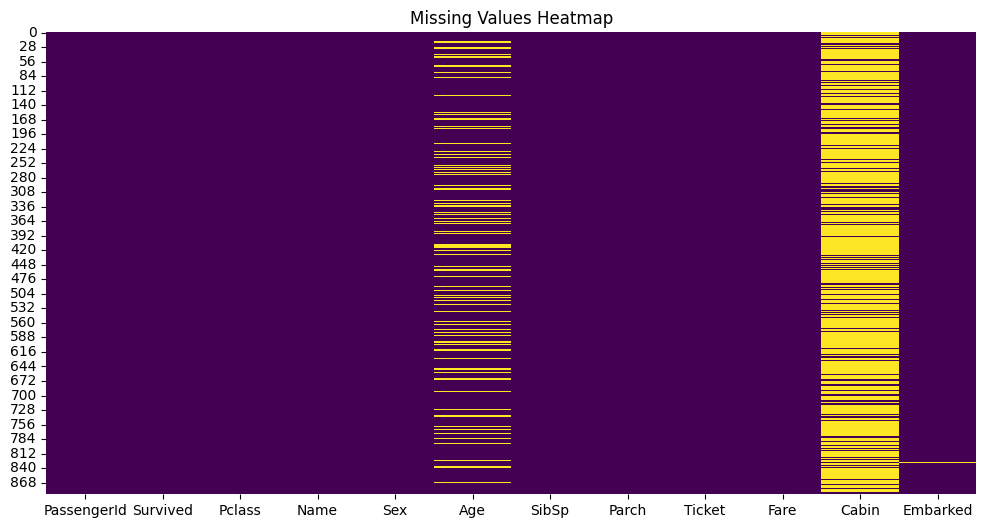

In [6]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing["Missing Values"] > 0]
missing.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


In [8]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.drop(columns=["Cabin"], inplace=True)

In [10]:
df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

In [11]:
df["Age"].median()

np.float64(28.0)

In [12]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [13]:
df["Embarked"].mode()

0    S
Name: Embarked, dtype: str

In [14]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [15]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [16]:
df.to_csv("cleaned_titanic.csv", index=False)

In [17]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [18]:
import pandas as pd

df = pd.read_csv("cleaned_titanic.csv")

In [19]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


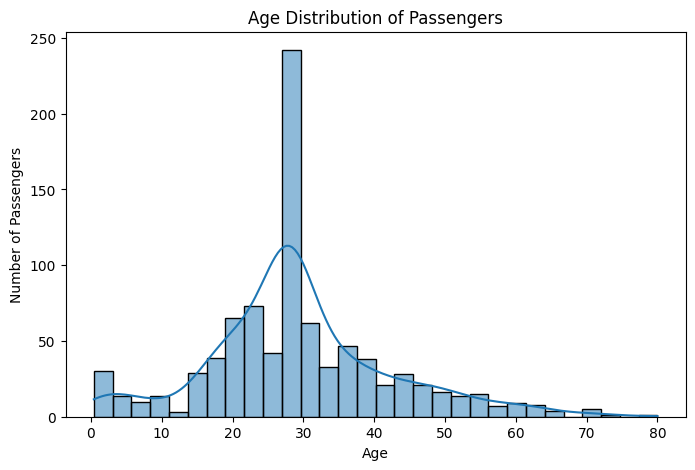

In [20]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df["Age"].dropna(), bins=30, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

# Save the graph inside the images folder
plt.savefig("images/age_distribution.png", dpi=300)

# Display the graph
plt.show()

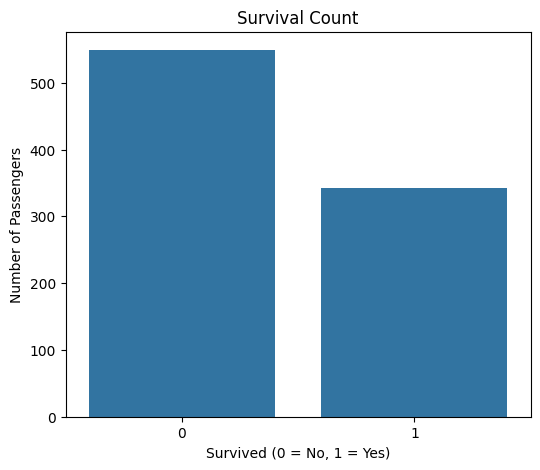

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(x="Survived", data=df)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.savefig("images/survival_count.png", dpi=300)

plt.show()

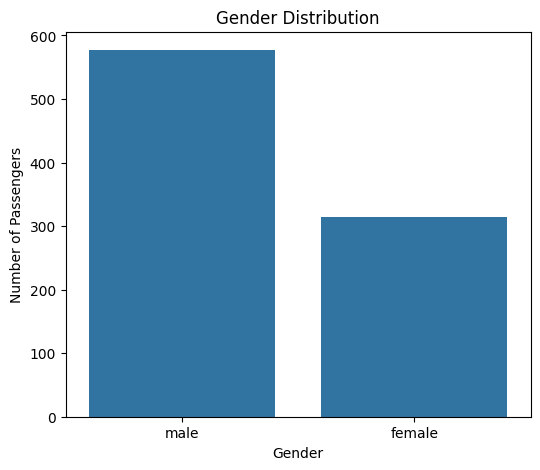

In [22]:
plt.figure(figsize=(6,5))

sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.savefig("images/gender_distribution.png", dpi=300)

plt.show()

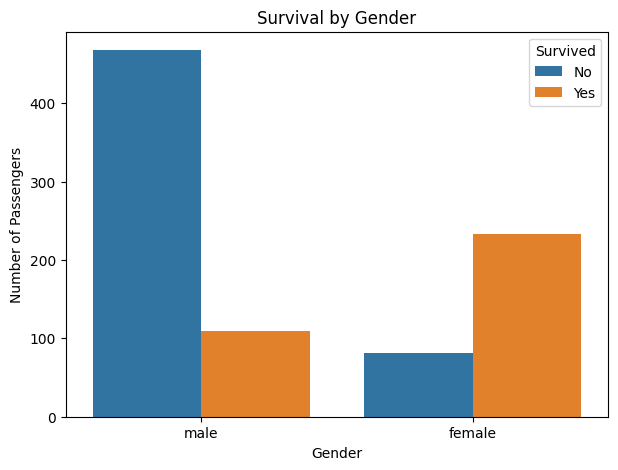

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.legend(title="Survived", labels=["No", "Yes"])

plt.savefig("images/survival_by_gender.png", dpi=300)

plt.show()

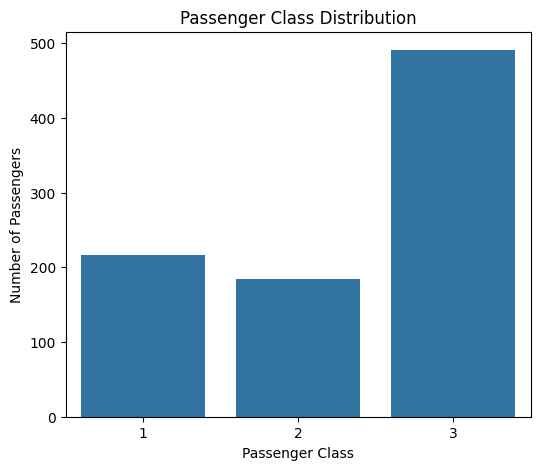

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.savefig("images/class_distribution.png", dpi=300)

plt.show()

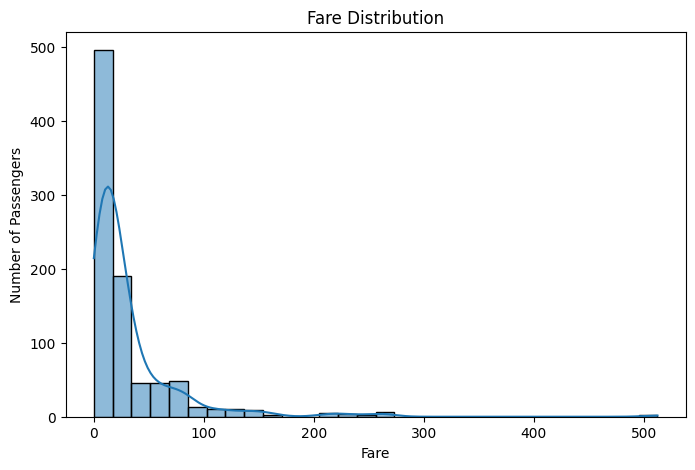

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["Fare"], bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.savefig("images/fare_distribution.png", dpi=300)

plt.show()

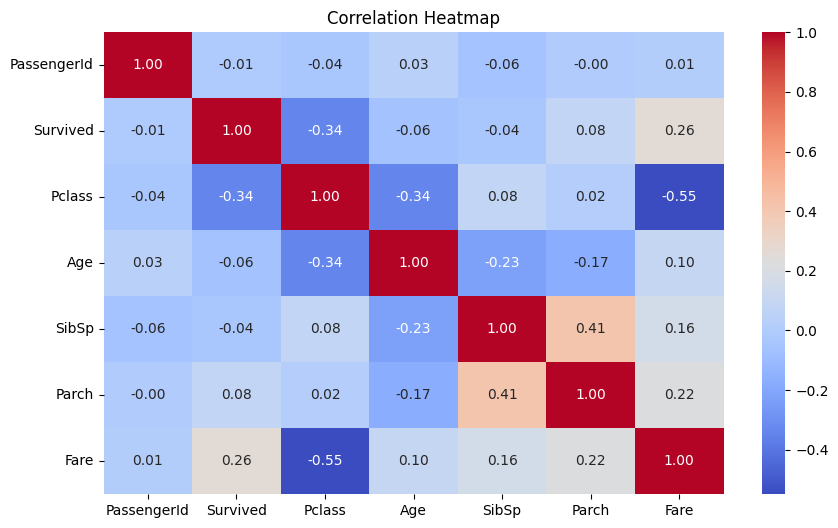

In [26]:
plt.figure(figsize=(10,6))
numeric_df=df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png", dpi=300)
plt.show()

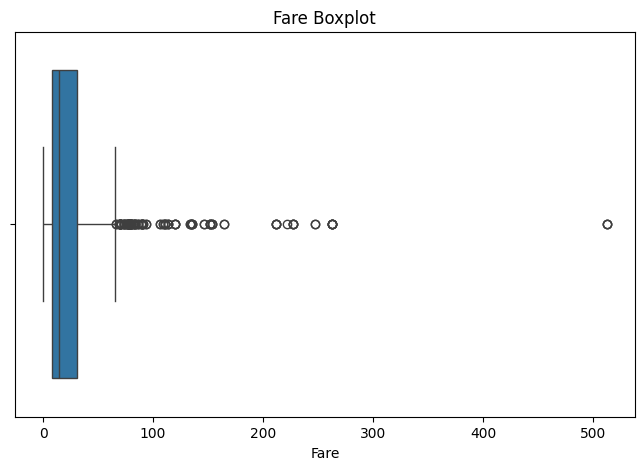

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot")
plt.savefig("images/fare_boxplot.png",dpi=300)
plt.show()

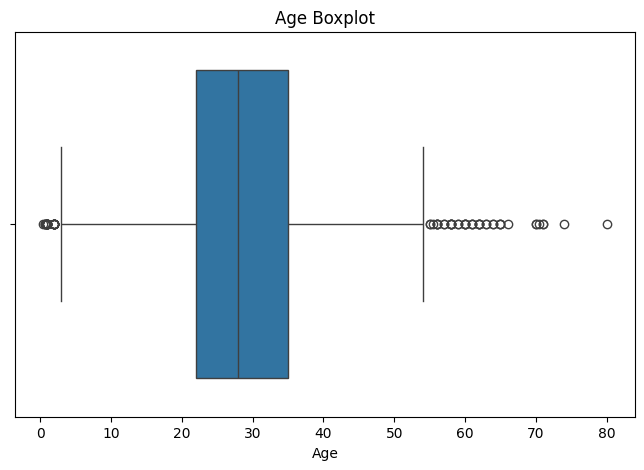

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Age"])
plt.title("Age Boxplot")
plt.savefig("images/age_boxplot.png", dpi=300)
plt.show()

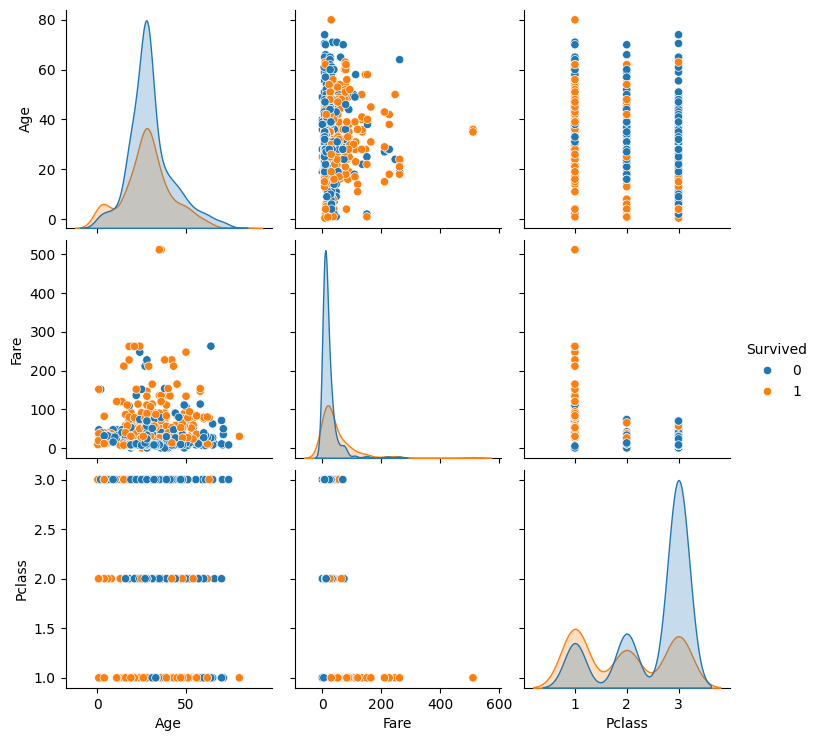

In [29]:
sns.pairplot(
    df[["Age", "Fare", "Pclass", "Survived"]],
    hue="Survived"
)

plt.savefig("images/pairplot.png", dpi=300)

plt.show()

In [30]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Fare"] < lower) | (df["Fare"] > upper)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 116
